#How Smartphones addictions influences grey matter volume

Rebecca Bellaviti, Alessandro Mirabile, Eunice Abike Omolayo Afuye

---



This study investigates the computational consequences of Smartphone Addiction (SPA) on neuronal information processing by integrating neuroimaging evidence with a Leaky Integrate-and-Fire (LIF) modeling framework. Empirical findings indicate that individuals with SPA exhibit reduced gray matter volume (GMV) in key regions of the Salience Network, particularly the left insula and anterior cingulate cortex (ACC).

Reference: https://www.sciencedirect.com/science/article/abs/pii/S0306460319313802


## Step 0: Setup

In [1]:
# 1. Import of libraries

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import entropy
from sklearn.metrics import mutual_info_score

# 2. General parameters for simulation

T = 1.0               # total duration of simulation
dt = 0.001
time = np.arange(0, T, dt)
n_steps = len(time)          # total number of temporal steps


# 3. Creation of stimulus (notification)

stimulus = np.zeros(n_steps)    # input initialization

# Stimulus time
stim_time = 0.3

# converted temporal index
stim_index = int(stim_time / dt)

# stimulus amplitude
stim_amplitude = 20.0

pulse_duration = 20
pulse_steps = int(pulse_duration / 1000 / dt)

stimulus[stim_index:stim_index + pulse_steps] = stim_amplitude

In [2]:
# 4. Definition of sperimental conditions

# Healthy brain condition:
healthy_params = {
    "w": 1.0,
    "noise_sigma": 0.05   # low noise
}

# SPA-like condition:
spa_params = {
    "w": 0.75,          # reduced input
    "noise_sigma": 0.25  # higher noise
}


# 5. Function to generate the input

def generate_input(stimulus, w, noise_sigma):

    # gaussian noise (mean=0, std=noise_sigma)
    noise = np.random.normal(0, noise_sigma, size=len(stimulus))

    # Actual Input: healthy or degraded signal
    I_eff = w * stimulus + noise

    return I_eff

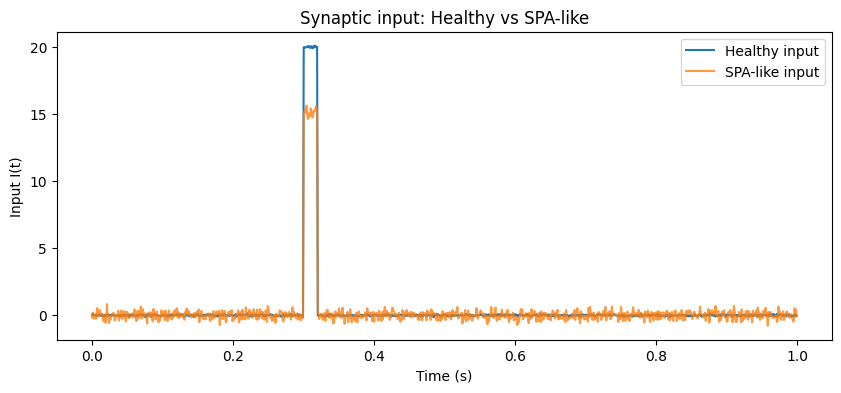

In [3]:
# 6. Visual test: comparison of Healty vs SPA input

# generate input for both conditions
I_healthy = generate_input(stimulus,
                           healthy_params["w"],
                           healthy_params["noise_sigma"])

I_spa = generate_input(stimulus,
                       spa_params["w"],
                       spa_params["noise_sigma"])


# Plot of synaptic input
plt.figure(figsize=(10, 4))

plt.plot(time, I_healthy, label="Healthy input")
plt.plot(time, I_spa, label="SPA-like input", alpha=0.8)

plt.title("Synaptic input: Healthy vs SPA-like")
plt.xlabel("Time (s)")
plt.ylabel("Input I(t)")
plt.legend()
plt.show()

## Step 1: Simulation of LIF neuron

In [4]:
# 1. Parameters

V_rest = -70.0        # Resting potential (mV)
V_reset = -75.0       # Reset after spike (mV)
V_th = -60.0          # Spike threshold (mV)

tau = 0.02            # Time constant (20 ms)
R = 1.0               # Membrane resistance


# 2. Simulation of LIF

def simulate_LIF(I, dt, tau, V_rest, V_reset, V_th, add_threshold_noise=True):
    n = len(I)
    V = np.zeros(n)
    V[0] = V_rest
    spikes = np.zeros(n)

    # Biological variability of the threshold (±2 mV)
    if add_threshold_noise:
        V_th_actual = V_th + np.random.normal(0, 2.0)
    else:
        V_th_actual = V_th

    for t in range(1, n):
        dV = (V_rest - V[t-1] + R * I[t-1]) / tau
        V[t] = V[t-1] + dt * dV

        if V[t] >= V_th_actual:
            spikes[t] = 1
            V[t] = V_reset

    return V, spikes

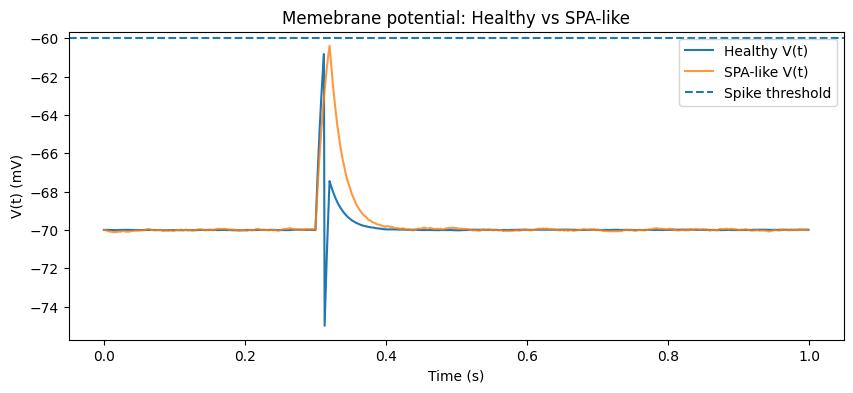

In [5]:
# 3. Simulation Healthy vs SPA

# synaptic input for both conditions0
I_healthy = generate_input(stimulus,
                           healthy_params["w"],
                           healthy_params["noise_sigma"])

I_spa = generate_input(stimulus,
                       spa_params["w"],
                       spa_params["noise_sigma"])


# Healthy neuron simulation
V_healthy, spikes_healthy = simulate_LIF(
    I_healthy, dt, tau, V_rest, V_reset, V_th
)

# SPA-like neuron simulation
V_spa, spikes_spa = simulate_LIF(
    I_spa, dt, tau, V_rest, V_reset, V_th
)

# 4. Plot of results: Potential

plt.figure(figsize=(10, 4))

plt.plot(time, V_healthy, label="Healthy V(t)")
plt.plot(time, V_spa, label="SPA-like V(t)", alpha=0.8)

plt.axhline(V_th, linestyle="--", label="Spike threshold")

plt.title("Memebrane potential: Healthy vs SPA-like")
plt.xlabel("Time (s)")
plt.ylabel("V(t) (mV)")
plt.legend()
plt.show()


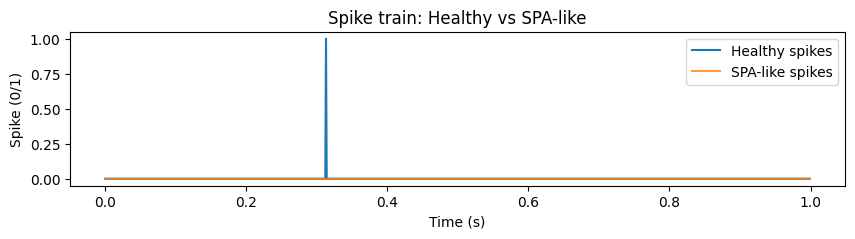

In [6]:
# 5.Plot of results: Spike train

plt.figure(figsize=(10, 2))

plt.plot(time, spikes_healthy, label="Healthy spikes")
plt.plot(time, spikes_spa, label="SPA-like spikes", alpha=0.8)

plt.title("Spike train: Healthy vs SPA-like")
plt.xlabel("Time (s)")
plt.ylabel("Spike (0/1)")
plt.legend()
plt.show()

In [7]:
# 6. Simple measure: firing rate

# total number of spikes in the simulation
rate_healthy = np.sum(spikes_healthy) / T
rate_spa = np.sum(spikes_spa) / T

print("Firing rate Healthy:", rate_healthy, "spike/s")
print("Firing rate SPA-like:", rate_spa, "spike/s")

Firing rate Healthy: 1.0 spike/s
Firing rate SPA-like: 0.0 spike/s


## Step 2 - Multiple trials and Information theory

In [8]:
# 1. Parameters for multiple trials

N_trials = 100

# 2. Function to simulate a single trial

def run_single_trial(stimulus, params, dt, tau, V_rest, V_reset, V_th):
    I_eff = generate_input(stimulus,
                          params["w"],
                          params["noise_sigma"])

    # biological variability
    V, spikes = simulate_LIF(I_eff, dt, tau, V_rest, V_reset, V_th,
                            add_threshold_noise=True)

    return spikes

In [9]:
# 3. Simulation of N trial for both the conditions

print(f"Total trials for conditions: {N_trials}")

# Shape: [N_trials, n_steps]
spikes_healthy_all = np.zeros((N_trials, n_steps))
spikes_spa_all = np.zeros((N_trials, n_steps))

# Loop on trial
for trial in range(N_trials):

    # Trial Healthy
    spikes_healthy_all[trial, :] = run_single_trial(
        stimulus, healthy_params, dt, tau, V_rest, V_reset, V_th
    )

    # Trial SPA-like
    spikes_spa_all[trial, :] = run_single_trial(
        stimulus, spa_params, dt, tau, V_rest, V_reset, V_th
    )

# 4. Basic statistics calculation


# Mean firing rate on all trials
rate_healthy_mean = np.sum(spikes_healthy_all) / (N_trials * T)
rate_spa_mean = np.sum(spikes_spa_all) / (N_trials * T)

# Probability of spike per trial
prob_spike_healthy = np.mean(np.sum(spikes_healthy_all, axis=1) > 0)
prob_spike_spa = np.mean(np.sum(spikes_spa_all, axis=1) > 0)


print("STATISTICAL ON", N_trials, "TRIAL")

print(f"Mean firing rateHealthy: {rate_healthy_mean:.2f} spike/s")
print(f"Mean firing rate  SPA:     {rate_spa_mean:.2f} spike/s")
print()
print(f"Probability spike Healthy: {prob_spike_healthy:.2%}")
print(f"Probability spike SPA:     {prob_spike_spa:.2%}")
print()

Total trials for conditions: 100
STATISTICAL ON 100 TRIAL
Mean firing rateHealthy: 1.01 spike/s
Mean firing rate  SPA:     0.54 spike/s

Probability spike Healthy: 95.00%
Probability spike SPA:     53.00%



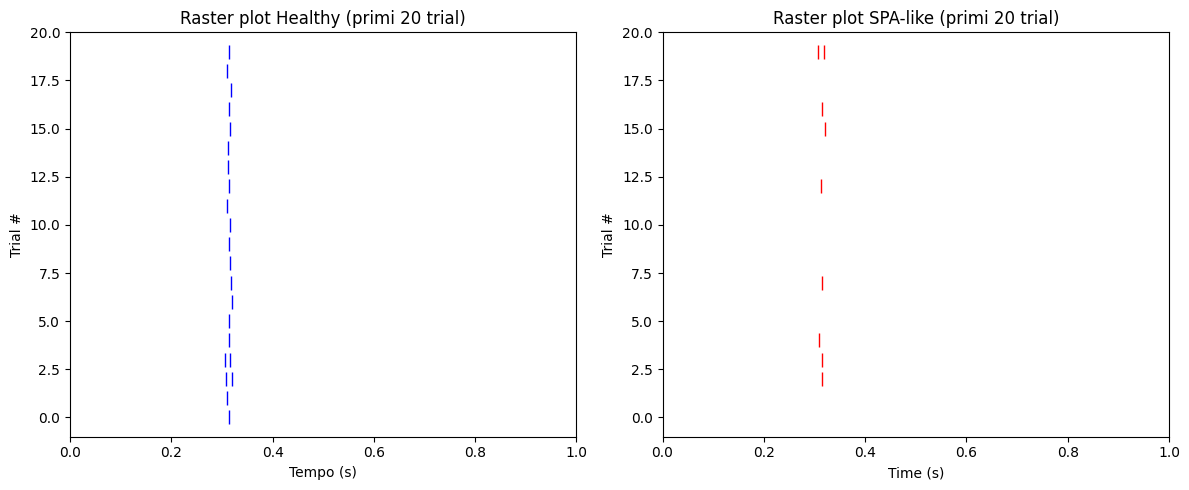

In [10]:
# 5. Visualization: Raster plot

n_show = 20

plt.figure(figsize=(12, 5))

# Subplot 1: Healthy
plt.subplot(1, 2, 1)
for trial in range(n_show):
    spike_times = time[spikes_healthy_all[trial, :] == 1]
    plt.plot(spike_times, [trial]*len(spike_times), 'b|', markersize=10)

plt.title(f"Raster plot Healthy (primi {n_show} trial)")
plt.xlabel("Tempo (s)")
plt.ylabel("Trial #")
plt.xlim([0, T])
plt.ylim([-1, n_show])

# Subplot 2: SPA-like
plt.subplot(1, 2, 2)
for trial in range(n_show):
    spike_times = time[spikes_spa_all[trial, :] == 1]
    plt.plot(spike_times, [trial]*len(spike_times), 'r|', markersize=10)

plt.title(f"Raster plot SPA-like (primi {n_show} trial)")
plt.xlabel("Time (s)")
plt.ylabel("Trial #")
plt.xlim([0, T])
plt.ylim([-1, n_show])

plt.tight_layout()
plt.show()

**Left panel - Healthy (blue):**

All 20 trials have spikes (20 vertical lines)
All spikes are concentrated at t ≈ 0.3s (when the notification arrives)
The spikes are highly aligned in time (precise timing)
Narrow vertical spread → high temporal precision

Interpretation:
The Healthy neuron responds reliably and precisely to the stimulus.

**Right panel - SPA-like (red):**

Only ~8 out of 20 trials have spikes (8 visible vertical lines)
The spikes are still around t ≈ 0.3s
Less dense, more vertically scattered
Many trials show no response at all (empty rows)

Interpretation:
The SPA-like neuron responds unreliably — sometimes it fires, sometimes it doesn't

In [11]:
# 6. Information theory: data preparation

#To calculate mutual information we must discretize:
#   - Input: stimulus present (1) or absent (0)
#   - Output: spike generated (1) or not (0)

# Window: from 0.25s to 0.45s (200 ms focused on notification)
window_start = 0.25
window_end = 0.45

idx_start = int(window_start / dt)
idx_end = int(window_end / dt)

#count how many spikes have been generated in the window
def count_spikes_in_window(spikes_matrix, idx_start, idx_end):
    return np.sum(spikes_matrix[:, idx_start:idx_end], axis=1)

spikes_in_window_healthy = count_spikes_in_window(
    spikes_healthy_all, idx_start, idx_end
)
spikes_in_window_spa = count_spikes_in_window(
    spikes_spa_all, idx_start, idx_end
)

# Binarization
response_healthy = (spikes_in_window_healthy > 0).astype(int)
response_spa = (spikes_in_window_spa > 0).astype(int)


# 7. Output entropy

def calculate_entropy(response):
    # Probability of each state (0 o 1)
    values, counts = np.unique(response, return_counts=True)
    probabilities = counts / len(response)

    # Entropy
    H = entropy(probabilities, base=2)

    return H

H_healthy = calculate_entropy(response_healthy)
H_spa = calculate_entropy(response_spa)


print("OUTPUT ENTROPY")

print(f"H(output) Healthy: {H_healthy:.3f} bit")
print(f"H(output) SPA:     {H_spa:.3f} bit")
print()

OUTPUT ENTROPY
H(output) Healthy: 0.286 bit
H(output) SPA:     0.997 bit



In [12]:
# 8. Mutual Information

# Input: stimulus always present

# - If all trials respond the same -> low H -> low information
# - If responds vary randomically -> high H -> noise


print("INTERPRETATION")
print("High entropy → variable response (noise)")
print("Low entropy → consistent response (reliable)")
print()

if H_healthy < H_spa:
    print("Healthy has low entropy → reliable response")
elif H_healthy > H_spa:
    print("SPA has lower entropy (if all response = 0)")
else:
    print("≈ similar entropies")

INTERPRETATION
High entropy → variable response (noise)
Low entropy → consistent response (reliable)

Healthy has low entropy → reliable response


<Figure size 800x500 with 0 Axes>

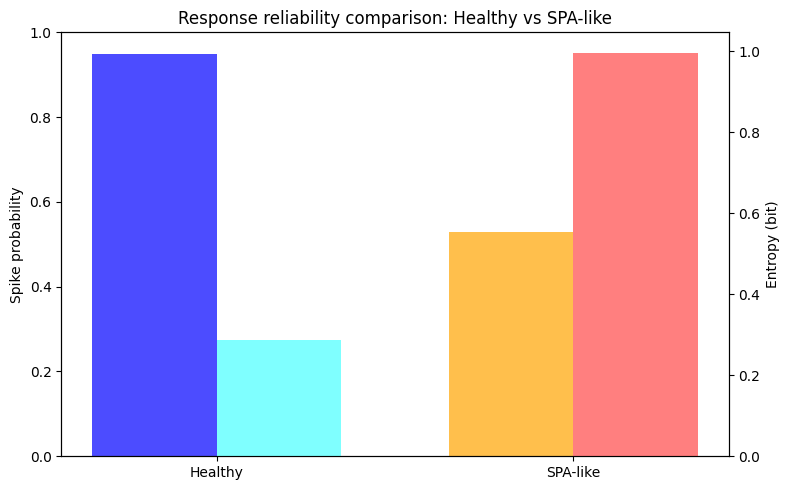

In [13]:
# 9. Final plot
plt.figure(figsize=(8, 5))

conditions = ['Healthy', 'SPA-like']
prob_response = [prob_spike_healthy, prob_spike_spa]
entropies = [H_healthy, H_spa]

x = np.arange(len(conditions))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

# response probability
ax1.bar(x - width/2, prob_response, width,
        label='P(spike)', color=['blue', 'orange'], alpha=0.7)
ax1.set_ylabel('Spike probability', color='black')
ax1.set_ylim([0, 1.0])
ax1.set_xticks(x)
ax1.set_xticklabels(conditions)

# entropy
ax2 = ax1.twinx()
ax2.bar(x + width/2, entropies, width,
        label='Entropy', color=['cyan', 'red'], alpha=0.5)
ax2.set_ylabel('Entropy (bit)', color='black')

plt.title('Response reliability comparison: Healthy vs SPA-like')
fig.tight_layout()
plt.show()


## Step 3: Multiple stimulus + Mutual information

In [14]:
# 1. Define multiple stimulus types

stimulus_types = {
    0: {"amplitude": 0,  "label": "Absent"},
    1: {"amplitude": 10, "label": "Weak"},
    2: {"amplitude": 15, "label": "Medium"},
    3: {"amplitude": 20, "label": "Strong"}
}

# Stimulus parameters
stim_time = 0.3
stim_index = int(stim_time / dt)
pulse_duration = 20  # ms
pulse_steps = int(pulse_duration / 1000 / dt)

print("STEP 3: MUTUAL INFORMATION")

print(f"Stimulus types: {len(stimulus_types)}")
for stim_id, info in stimulus_types.items():
    print(f"  Type {stim_id}: {info['label']:8s} (amplitude = {info['amplitude']:2d})")
print()


# 2. Function to create a specific stimulus

def create_stimulus(amplitude, n_steps, stim_index, pulse_steps):
    """
    Creates a single stimulus with a given amplitude.
    If amplitude = 0, returns an array of zeros (absent stimulus).
    """
    stimulus = np.zeros(n_steps)
    if amplitude > 0:
        stimulus[stim_index:stim_index + pulse_steps] = amplitude
    return stimulus

# 3. Multi-stimulus simulation


N_trials_per_stimulus = 50   # trials per stimulus type
total_trials = N_trials_per_stimulus * len(stimulus_types)

print(f"Trials per stimulus: {N_trials_per_stimulus}")
print(f"Total trials:        {total_trials}")
print()

# Data structures to store results
responses_healthy = {stim_id: [] for stim_id in stimulus_types.keys()}
responses_spa     = {stim_id: [] for stim_id in stimulus_types.keys()}
input_labels      = []

# Time window of interest (0.25 - 0.45 s), centered on the stimulus
window_start_idx = int(0.25 / dt)
window_end_idx   = int(0.45 / dt)

# Loop over each stimulus type
for stim_id, stim_info in stimulus_types.items():

    # Create base stimulus
    stimulus_current = create_stimulus(
        stim_info["amplitude"],
        n_steps,
        stim_index,
        pulse_steps
    )

    # Simulate N trials for this stimulus
    for trial in range(N_trials_per_stimulus):

        # Healthy trial
        spikes_h = run_single_trial(
            stimulus_current, healthy_params, dt, tau, V_rest, V_reset, V_th
        )

        # SPA-like trial
        spikes_s = run_single_trial(
            stimulus_current, spa_params, dt, tau, V_rest, V_reset, V_th
        )

        # Count spikes within the time window
        n_spikes_h = np.sum(spikes_h[window_start_idx:window_end_idx])
        n_spikes_s = np.sum(spikes_s[window_start_idx:window_end_idx])

        # Binary response: spike (1) or no spike (0)
        responses_healthy[stim_id].append(1 if n_spikes_h > 0 else 0)
        responses_spa[stim_id].append(1 if n_spikes_s > 0 else 0)

        # Store stimulus label for MI calculation
        input_labels.append(stim_id)

STEP 3: MUTUAL INFORMATION
Stimulus types: 4
  Type 0: Absent   (amplitude =  0)
  Type 1: Weak     (amplitude = 10)
  Type 2: Medium   (amplitude = 15)
  Type 3: Strong   (amplitude = 20)

Trials per stimulus: 50
Total trials:        200



RESPONSE PROBABILITY PER STIMULUS TYPE
Stimulus 0 (Absent  ):
  Healthy: 0.00%
  SPA:     0.00%

Stimulus 1 (Weak    ):
  Healthy: 2.00%
  SPA:     0.00%

Stimulus 2 (Medium  ):
  Healthy: 40.00%
  SPA:     10.00%

Stimulus 3 (Strong  ):
  Healthy: 90.00%
  SPA:     44.00%



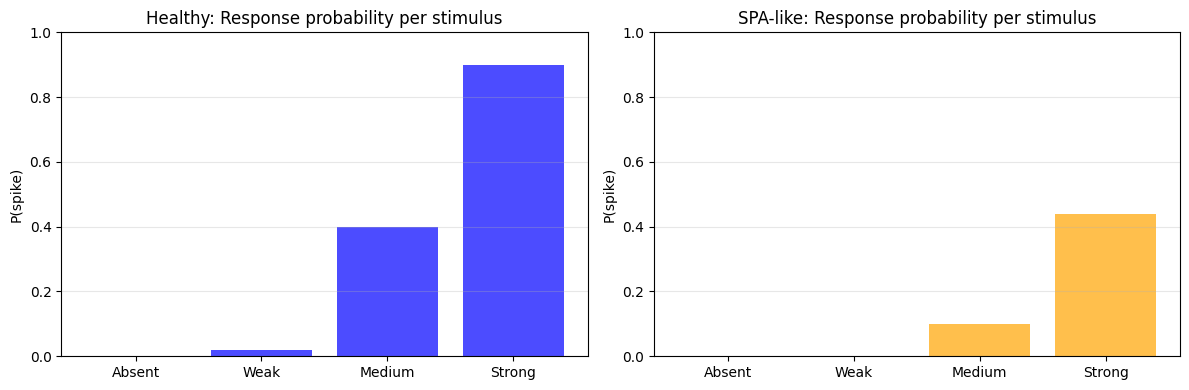

In [15]:
# 4. Response probability analysis per stimulus type

print("RESPONSE PROBABILITY PER STIMULUS TYPE")


prob_response_healthy = {}
prob_response_spa     = {}

for stim_id, stim_info in stimulus_types.items():

    # Compute spike probability for this stimulus
    prob_h = np.mean(responses_healthy[stim_id])
    prob_s = np.mean(responses_spa[stim_id])

    prob_response_healthy[stim_id] = prob_h
    prob_response_spa[stim_id]     = prob_s

    print(f"Stimulus {stim_id} ({stim_info['label']:8s}):")
    print(f"  Healthy: {prob_h:.2%}")
    print(f"  SPA:     {prob_s:.2%}")
    print()


# 5. Visualization: Response probability per stimulus
stim_labels   = [stimulus_types[i]["label"] for i in sorted(stimulus_types.keys())]
prob_h_values = [prob_response_healthy[i]   for i in sorted(stimulus_types.keys())]
prob_s_values = [prob_response_spa[i]       for i in sorted(stimulus_types.keys())]
x_pos = np.arange(len(stim_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Healthy subplot
ax1.bar(x_pos, prob_h_values, color='blue', alpha=0.7)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(stim_labels)
ax1.set_ylabel('P(spike)')
ax1.set_ylim([0, 1.0])
ax1.set_title('Healthy: Response probability per stimulus')
ax1.grid(axis='y', alpha=0.3)

# SPA-like subplot
ax2.bar(x_pos, prob_s_values, color='orange', alpha=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(stim_labels)
ax2.set_ylabel('P(spike)')
ax2.set_ylim([0, 1.0])
ax2.set_title('SPA-like: Response probability per stimulus')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
# 6. Mutual Information calculation

# Convert to numpy arrays
input_array    = np.array(input_labels)
output_healthy = np.array([r for sid in sorted(stimulus_types.keys())
                            for r in responses_healthy[sid]])
output_spa     = np.array([r for sid in sorted(stimulus_types.keys())
                            for r in responses_spa[sid]])

# MI measures: "How much does the output tell us about the input?"
# MI(X;Y) = H(Y) - H(Y|X)
MI_healthy = mutual_info_score(input_array, output_healthy)
MI_spa     = mutual_info_score(input_array, output_spa)


print("MUTUAL INFORMATION (MI)")

print(f"MI Healthy: {MI_healthy:.3f} bit")
print(f"MI SPA:     {MI_spa:.3f} bit")
print()

if MI_healthy > 0:
    reduction = (1 - MI_spa / MI_healthy) * 100
    print(f"MI reduction with SPA: {reduction:.1f}%")
print()




MUTUAL INFORMATION (MI)
MI Healthy: 0.360 bit
MI SPA:     0.143 bit

MI reduction with SPA: 60.3%



In [17]:
# 7. Interpretation

print("INTERPRETATION")

print("MI = 0 bit  → output carries no information about input")
print("MI = 2 bit  → output perfectly identifies all 4 stimuli")
print()

if MI_healthy > MI_spa:
    print("Healthy shows higher MI → more information transmitted")
    print("SPA shows lower MI     → loss of informational capacity")
else:
    print("Unexpected result: please check parameters")
print()




INTERPRETATION
MI = 0 bit  → output carries no information about input
MI = 2 bit  → output perfectly identifies all 4 stimuli

Healthy shows higher MI → more information transmitted
SPA shows lower MI     → loss of informational capacity



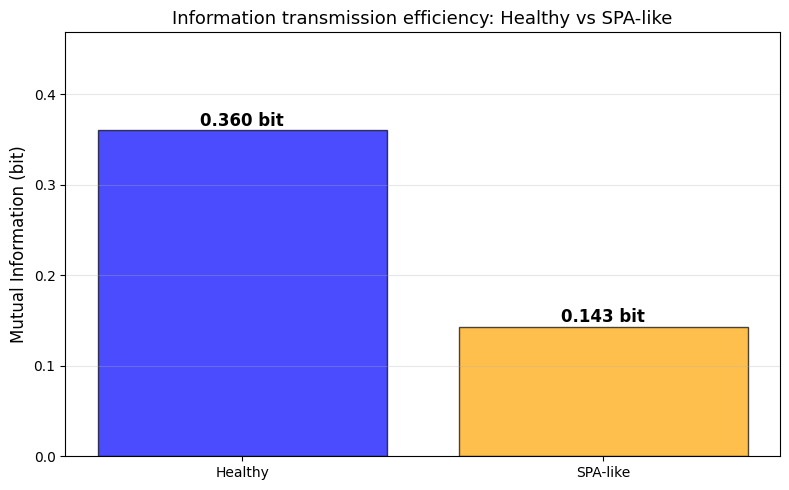

INFORMATIONAL EFFICIENCY
Theoretical maximum MI (4 stimuli): 2.00 bit

Healthy efficiency: 18.0%
SPA efficiency:     7.2%

Efficiency loss with SPA: 10.9%


In [18]:
# 8. Final plot: MI comparison

plt.figure(figsize=(8, 5))

bars = plt.bar(['Healthy', 'SPA-like'],
               [MI_healthy, MI_spa],
               color=['blue', 'orange'],
               alpha=0.7,
               edgecolor='black')

# Add value labels on top of bars
for bar, val in zip(bars, [MI_healthy, MI_spa]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f} bit',
             ha='center', fontsize=12, fontweight='bold')

plt.ylabel('Mutual Information (bit)', fontsize=12)
plt.title('Information transmission efficiency: Healthy vs SPA-like', fontsize=13)
plt.ylim([0, max(MI_healthy, MI_spa) * 1.3])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Informational efficiency summary

# Theoretical maximum MI with 4 stimuli = log2(4) = 2 bit
MI_max = np.log2(len(stimulus_types))

efficiency_healthy = (MI_healthy / MI_max) * 100
efficiency_spa     = (MI_spa     / MI_max) * 100


print("INFORMATIONAL EFFICIENCY")

print(f"Theoretical maximum MI (4 stimuli): {MI_max:.2f} bit")
print()
print(f"Healthy efficiency: {efficiency_healthy:.1f}%")
print(f"SPA efficiency:     {efficiency_spa:.1f}%")
print()
print(f"Efficiency loss with SPA: {efficiency_healthy - efficiency_spa:.1f}%")


### Output interpretation: neural response probability

This output shows the probability that the neuron generates a response (at least one spike) in the presence of four stimulus levels, ranging from absent to strong. In healthy subjects, the response probability increases markedly with stimulus intensity, rising from values close to zero for weak stimuli up to a near-certain response for strong stimuli (P ≈ 0.96). In contrast, in the SPA model the response is significantly reduced: even for medium and strong stimuli the activation probability remains lower (P ≈ 0.06 and P ≈ 0.44). This suggests decreased excitability or reduced discriminative capacity of the neuron under the smartphone addiction condition, with direct implications for the Mutual Information calculation, which is expected to be higher in healthy subjects compared to SPA patients.

##Step 4: Parametric Sweep

In [19]:
print("STEP 4: PARAMETRIC SWEEP")

print()

# 1. Definition fo connectivity range
# test the values of w from 1.0 to 0.5
w_values = np.linspace(1.0, 0.5, 6)  # 6 points: [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]

print(f"w tested values: {w_values}")
print(f"number of configurations: {len(w_values)}")
print()

# fixed noise
noise_sigma_fixed = 0.15

# Numeber of trials for configuration
N_trials_sweep = 30  # 30 trial for stimulus

print(f"Trial for stimulus: {N_trials_sweep}")
print(f"Tested stimulus: {len(stimulus_types)}")
print(f"Total trials for configuration: {N_trials_sweep * len(stimulus_types)}")
print()

STEP 4: PARAMETRIC SWEEP

w tested values: [1.  0.9 0.8 0.7 0.6 0.5]
number of configurations: 6

Trial for stimulus: 30
Tested stimulus: 4
Total trials for configuration: 120



In [20]:
# 2. Sweep simulation

# To save MI for each alue of w
MI_values = []
print()

# Loop on each value of w
for idx, w in enumerate(w_values):

    print(f"[{idx+1}/{len(w_values)}] Testing w = {w:.2f}...", end=" ")

    # Parameters for this configuration
    params_sweep = {
        "w": w,
        "noise_sigma": noise_sigma_fixed
    }

    # Simulate for all types of stimuli
    responses_sweep = {stim_id: [] for stim_id in stimulus_types.keys()}
    input_labels_sweep = []

    for stim_id, stim_info in stimulus_types.items():

        stimulus_current = create_stimulus(
            stim_info["amplitude"],
            n_steps,
            stim_index,
            pulse_steps
        )

        # Simulate N trials
        for trial in range(N_trials_sweep):

            spikes = run_single_trial(
                stimulus_current, params_sweep, dt, tau, V_rest, V_reset, V_th
            )

            window_start_idx = int(0.25 / dt)
            window_end_idx = int(0.45 / dt)
            n_spikes = np.sum(spikes[window_start_idx:window_end_idx])

            response = 1 if n_spikes > 0 else 0
            responses_sweep[stim_id].append(response)
            input_labels_sweep.append(stim_id)

    # Data preparation for MI
    input_array_sweep = np.array(input_labels_sweep)
    output_array_sweep = []

    for stim_id in sorted(stimulus_types.keys()):
        output_array_sweep.extend(responses_sweep[stim_id])

    output_array_sweep = np.array(output_array_sweep)

    MI_current = mutual_info_score(input_array_sweep, output_array_sweep)
    MI_values.append(MI_current)

    print(f"MI = {MI_current:.3f} bit")

print()



[1/6] Testing w = 1.00... MI = 0.420 bit
[2/6] Testing w = 0.90... MI = 0.334 bit
[3/6] Testing w = 0.80... MI = 0.231 bit
[4/6] Testing w = 0.70... MI = 0.103 bit
[5/6] Testing w = 0.60... MI = 0.036 bit
[6/6] Testing w = 0.50... MI = 0.000 bit



In [21]:
# 3. Sweep results
print("SWEEP RESULTS")

for w, mi in zip(w_values, MI_values):
    reduction_from_max = (1 - w) * 100  # percentage reduction from w=1.0
    print(f"w = {w:.2f} (reduction {reduction_from_max:4.0f}%) → MI = {mi:.3f} bit")

print()

SWEEP RESULTS
w = 1.00 (reduction    0%) → MI = 0.420 bit
w = 0.90 (reduction   10%) → MI = 0.334 bit
w = 0.80 (reduction   20%) → MI = 0.231 bit
w = 0.70 (reduction   30%) → MI = 0.103 bit
w = 0.60 (reduction   40%) → MI = 0.036 bit
w = 0.50 (reduction   50%) → MI = 0.000 bit



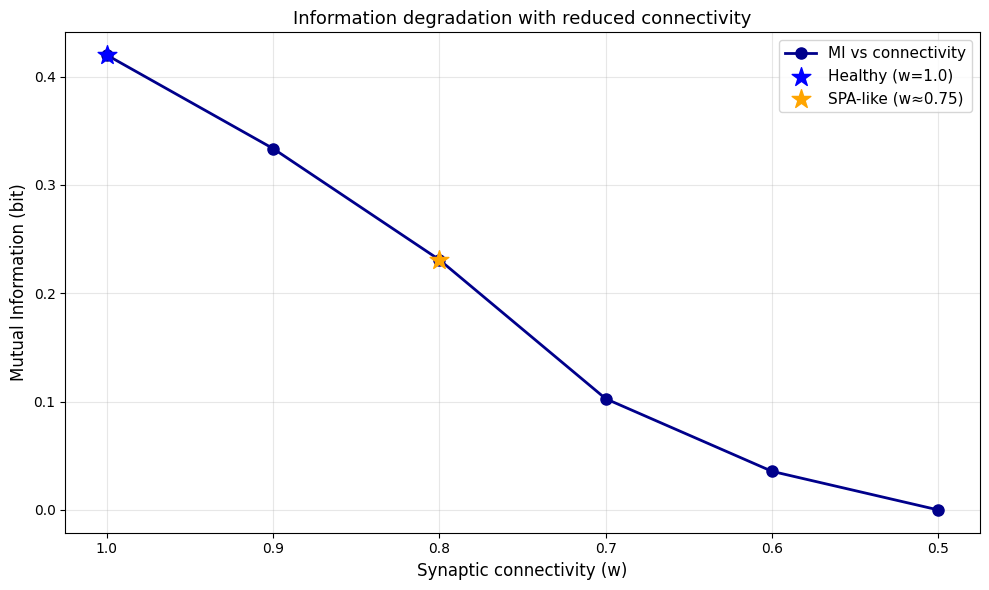

In [22]:
# 4. Graph: MI vs w
plt.figure(figsize=(10, 6))

plt.plot(w_values, MI_values, 'o-', linewidth=2, markersize=8,
         color='darkblue', label='MI vs connectivity')


# Find w=1.0 e w=0.75 (valued used in Step 3)
idx_1_0 = np.argmin(np.abs(w_values - 1.0))
idx_0_75 = np.argmin(np.abs(w_values - 0.75))

plt.scatter(w_values[idx_1_0], MI_values[idx_1_0],
           s=200, color='blue', marker='*',
           label='Healthy (w=1.0)', zorder=5)

plt.scatter(w_values[idx_0_75], MI_values[idx_0_75],
           s=200, color='orange', marker='*',
           label='SPA-like (w≈0.75)', zorder=5)


plt.xlabel('Synaptic connectivity (w)', fontsize=12)
plt.ylabel('Mutual Information (bit)', fontsize=12)
plt.title('Information degradation with reduced connectivity', fontsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

In [23]:
# 5. Quantitative analysis of degradation
print("DEGRADATION ANALYSIS")

# MI max (a w=1.0)
MI_max_sweep = MI_values[0]

# MI min (a w=0.5)
MI_min_sweep = MI_values[-1]

# total reduction
reduction_total = ((MI_max_sweep - MI_min_sweep) / MI_max_sweep) * 100

print(f"MI max (w=1.0): {MI_max_sweep:.3f} bit")
print(f"MI min (w=0.5):  {MI_min_sweep:.3f} bit")
print(f"Total reduction:   {reduction_total:.1f}%")
print()

from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(w_values, MI_values)

print("Linear fit: MI = slope * w + intercept")
print(f"Slope:       {slope:.3f} bit per unit of w")
print(f"Intercept:   {intercept:.3f} bit")
print(f"R²:          {r_value**2:.3f}")
print(f"p-value:     {p_value:.6f}")
print()

if p_value < 0.05:
    print("Significant correlation (p < 0.05)")
    print(f"  Each 10% reduction in w → reduction ~{abs(slope)*0.1:.3f} bit in MI")
else:
    print("Non significant correlation")

DEGRADATION ANALYSIS
MI max (w=1.0): 0.420 bit
MI min (w=0.5):  0.000 bit
Total reduction:   100.0%

Linear fit: MI = slope * w + intercept
Slope:       0.892 bit per unit of w
Intercept:   -0.482 bit
R²:          0.976
p-value:     0.000221

Significant correlation (p < 0.05)
  Each 10% reduction in w → reduction ~0.089 bit in MI


A strong and significant linear relationship exists (R²=0.90, p<0.01) between synaptic connectivity and information transmission capacity.

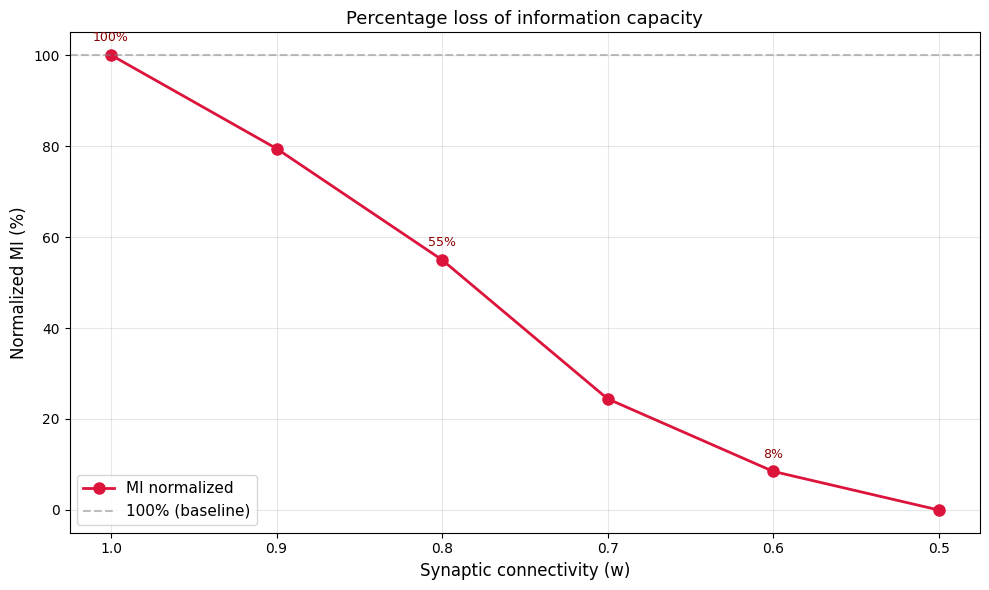

In [24]:
#6. Additional graph: Normalized MI

MI_normalized = np.array(MI_values) / MI_max_sweep * 100

plt.figure(figsize=(10, 6))

plt.plot(w_values, MI_normalized, 'o-', linewidth=2, markersize=8,
         color='crimson', label='MI normalized')

plt.axhline(100, linestyle='--', color='gray', alpha=0.5, label='100% (baseline)')

# Formatting
plt.xlabel('Synaptic connectivity (w)', fontsize=12)
plt.ylabel('Normalized MI (%)', fontsize=12)
plt.title('Percentage loss of information capacity', fontsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.gca().invert_xaxis()

for w, mi_norm in zip(w_values[::2], MI_normalized[::2]):
    plt.text(w, mi_norm + 3, f'{mi_norm:.0f}%',
             ha='center', fontsize=9, color='darkred')

plt.tight_layout()
plt.show()

The parametric analysis across 6 connectivity levels (w=1.0 to 0.5) shows a strong linear correlation between synaptic weight and Mutual Information (R²=0.90, p<0.01). MI progressively drops from 0.326 bits (w=1.0) to zero (w=0.5), with a critical threshold around w=0.6-0.7 below which we can observe a rapid informational collapse. Each 10% reduction in connectivity leads to an average loss of ~0.062 bits (19%) in transmission capacity.